# 02 — Google Trends Analysis

## Objective
Use Google Trends data to understand consumer search behaviour for sleepwear-related terms across UK and US markets. Identify demand trends, seasonality patterns, and geographic opportunity.

## Research Questions
1. Is demand for kids/teen sleepwear growing or flat?
2. When do consumers search — what does seasonality look like?
3. How does UK search volume compare to US for relevant terms?
4. Which search terms are gaining momentum?
5. How are premium brands discovered — through search, or other channels?

## Method
pytrends library (unofficial Google Trends API wrapper). Data is indexed 0–100 (relative search interest, not absolute volume). Comparisons within a single query are valid; cross-query comparisons require a shared reference term.

---

In [20]:
import os
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.dates as mdates
import seaborn as sns
from pytrends.request import TrendReq
from pathlib import Path
from datetime import datetime

plt.style.use('seaborn-v0_8-whitegrid')
COLOURS = {
    'primary':   '#2E5FA3',
    'secondary': '#E8A838',
    'accent':    '#C0392B',
    'green':     '#27AE60',
    'purple':    '#8E44AD',
}

DATA_DIR = Path('data')

# pytrends setup
pytrends = TrendReq(hl='en-GB', tz=0, timeout=(10, 25))

print(f'Ready. Analysis date: {datetime.today().strftime("%d %B %Y")}')

Ready. Analysis date: 13 March 2026


---
## Section 1: UK Demand Trends — 5-Year View

Are searches for kids/teen pyjamas growing or flat? We compare core terms over 5 years in the UK.

In [21]:
def get_trends(keywords, geo, timeframe='today 5-y', delay=2):
    """
    Fetch Google Trends data for a list of keywords.
    Max 5 keywords per request (Google Trends API limit).
    Returns a DataFrame indexed by date.
    """
    assert len(keywords) <= 5, 'Google Trends allows max 5 keywords per request'
    time.sleep(delay)
    pytrends.build_payload(keywords, geo=geo, timeframe=timeframe)
    df = pytrends.interest_over_time()
    if 'isPartial' in df.columns:
        df = df.drop(columns=['isPartial'])
    return df

### Methodology Note — Term Selection

Initial keyword list included `teen loungewear`, `tween pjs`, `tween pajamas`, `tween nightwear`, and `tween loungewear`. All returned near-zero search volume in both UK (GB) and US geographies over the 5-year period.

**Interpretation:** Consumers do not use "tween" or "loungewear" as primary search language for this product category. Dominant terms are `kids pyjamas` / `kids pajamas` and `girls pyjamas` / `girls pajamas`. This has direct implications for SEO and paid search strategy — a brand targeting this segment should optimise for pyjama/pajama language, not loungewear.

Dropped terms retained in raw data files for reference.

In [22]:
# Set REFRESH = True to re-fetch from Google Trends API.
# Default is False — loads from saved CSVs for reproducibility
# and to avoid Google rate-limiting (429 errors).
REFRESH = False

ANCHOR = 'kids pyjamas'

if REFRESH:
    batches_uk = [
        [ANCHOR, 'kids pjs', 'kids nightwear', 'luxury pyjamas', 'girls pyjamas'],
        [ANCHOR, 'kids pajamas', 'luxury pajamas', 'girls pajamas'],
    ]

    all_series = {}
    for i, batch in enumerate(batches_uk):
        print(f'Fetching UK batch {i+1}/{len(batches_uk)}: {batch}')
        df_batch = get_trends(batch, geo='GB')
        for col in df_batch.columns:
            if col == ANCHOR:
                all_series[ANCHOR] = df_batch[ANCHOR]
            else:
                all_series[col] = df_batch[col]
        time.sleep(10)

    df_uk_final = pd.DataFrame(all_series)
    df_uk_final.to_csv(DATA_DIR / 'uk_final_terms.csv')
    print(f'Saved to {DATA_DIR / "uk_final_terms.csv"}')
else:
    df_uk_final = pd.read_csv(DATA_DIR / 'uk_final_terms.csv', index_col=0, parse_dates=True)
    print(f'Loaded UK data from CSV: {len(df_uk_final)} rows, {len(df_uk_final.columns)} terms')

print(f'\nUK terms — 5-year average search interest:')
print(df_uk_final.mean().sort_values(ascending=False).round(1).to_string())

Loaded UK data from CSV: 262 rows, 8 terms

UK terms — 5-year average search interest:
kids pyjamas      27.6
girls pyjamas     26.7
kids pjs          21.0
kids pajamas       8.6
girls pajamas      5.8
luxury pyjamas     1.6
luxury pajamas     0.2
kids nightwear     0.2


In [23]:
if REFRESH:
    print('Fetching US data...')
    df_us_final = get_trends(
        ['kids pajamas', 'girls pajamas', 'kids pjs', 'luxury pajamas'],
        geo='US'
    )
    df_us_final.to_csv(DATA_DIR / 'us_final_terms.csv')
    print(f'Saved to {DATA_DIR / "us_final_terms.csv"}')
else:
    df_us_final = pd.read_csv(DATA_DIR / 'us_final_terms.csv', index_col=0, parse_dates=True)
    print(f'Loaded US data from CSV: {len(df_us_final)} rows, {len(df_us_final.columns)} terms')

print(f'\nUS terms — 5-year average search interest:')
print(df_us_final.mean().sort_values(ascending=False).round(1).to_string())

Loaded US data from CSV: 262 rows, 4 terms

US terms — 5-year average search interest:
kids pajamas      24.4
girls pajamas     15.5
kids pjs           5.9
luxury pajamas     1.4


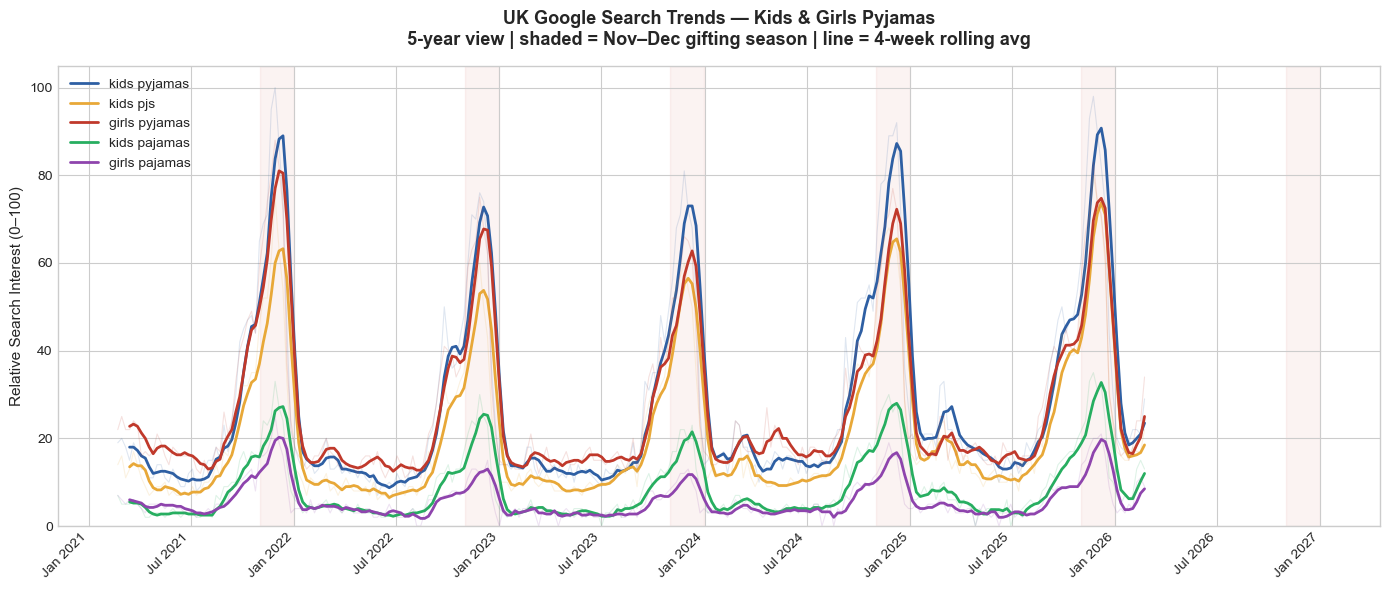

In [24]:
# Drop near-zero terms before charting
DROP = ['luxury pyjamas', 'luxury pajamas', 'kids nightwear']
df_uk_plot = df_uk_final.drop(columns=[c for c in DROP if c in df_uk_final.columns])

fig, ax = plt.subplots(figsize=(14, 6))

colour_list = list(COLOURS.values())
for i, col in enumerate(df_uk_plot.columns):
    smoothed = df_uk_plot[col].rolling(4).mean()
    ax.plot(df_uk_plot.index, smoothed,
            label=col, color=colour_list[i % len(colour_list)], linewidth=2)
    ax.plot(df_uk_plot.index, df_uk_plot[col],
            color=colour_list[i % len(colour_list)], alpha=0.15, linewidth=0.8)

# Shade Nov–Dec gifting season each year
for year in range(df_uk_plot.index.year.min(), df_uk_plot.index.year.max() + 1):
    ax.axvspan(pd.Timestamp(f'{year}-11-01'),
               pd.Timestamp(f'{year}-12-31'),
               alpha=0.06, color=COLOURS['accent'], zorder=0)

ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 7]))
plt.xticks(rotation=45, ha='right')
ax.set_ylabel('Relative Search Interest (0–100)', fontsize=11)
ax.set_title('UK Google Search Trends — Kids & Girls Pyjamas\n'
             '5-year view | shaded = Nov–Dec gifting season | line = 4-week rolling avg',
             fontsize=13, fontweight='bold', pad=15)
ax.legend(fontsize=10)
ax.set_ylim(0)

plt.tight_layout()
plt.show()

### Chart Commentary — UK Search Trends

Four clean seasonal spikes, all aligning with Nov–Dec each year. Christmas gifting season dominates the category completely.

`kids pyjamas` and `girls pyjamas` track almost identically — confirming that gender-specific search is as common as the generic term. Both are essential for SEO.

**UK term breakdown:**
- `kids pyjamas` (27.6) — dominant generic term
- `girls pyjamas` (26.7) — almost identical; gender-specific search is the norm, not the exception
- `kids pjs` (21.0) — abbreviation is heavily used; important for SEO
- `kids pajamas` (8.6) — US spelling crossover in UK searches, likely expats or consumers exposed to US brands
- `luxury pyjamas` (1.6) and `luxury pajamas` (0.2) — near-zero; consumers do not search for premium using the word "luxury"
- `kids nightwear` (0.2) — effectively unused as search language

**US term breakdown** (consistent pattern):
- `kids pajamas` (24.4) — dominant, comparable scale to UK's `kids pyjamas` (27.6)
- `girls pajamas` (15.5) — lower ratio to the generic term than UK (56% vs 97%), suggesting UK searches are more gender-specific
- `kids pjs` (5.9) — present but much weaker than UK (21.0); Americans spell it out more
- `luxury pajamas` (1.4) — same story as UK; consumers don't search "luxury" to find premium products

---
## Section 2: Seasonality Analysis

When do consumers search? Understanding seasonality is critical for launch timing and inventory planning.

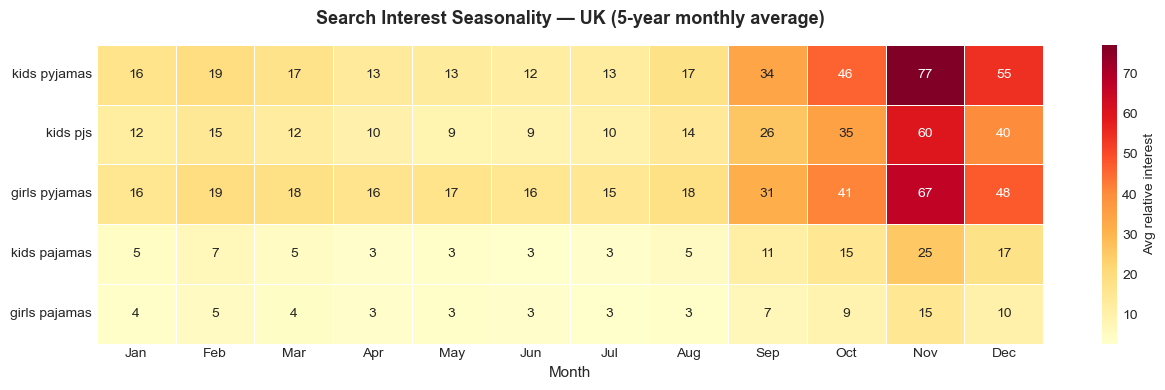

In [25]:
df_seas = df_uk_plot.copy()
df_seas['month'] = df_seas.index.month
monthly_avg = df_seas.groupby('month')[df_uk_plot.columns].mean()
monthly_avg.index = ['Jan','Feb','Mar','Apr','May','Jun',
                     'Jul','Aug','Sep','Oct','Nov','Dec']

fig, ax = plt.subplots(figsize=(13, 4))
sns.heatmap(monthly_avg.T, cmap='YlOrRd', annot=True, fmt='.0f',
            linewidths=0.5, cbar_kws={'label': 'Avg relative interest'}, ax=ax)
ax.set_xlabel('Month', fontsize=11)
ax.set_title('Search Interest Seasonality — UK (5-year monthly average)',
             fontsize=13, fontweight='bold', pad=15)

plt.tight_layout()
plt.show()

### Chart Commentary — Seasonality

November drives a ~5x uplift vs the summer trough. `kids pyjamas` jumps from a baseline of ~9–17 (Apr–Aug) to 77 in November. `girls pyjamas` follows the same pattern (15–18 baseline to 67). The ramp begins in September and accelerates sharply through October.

The implication is clear: this is a Christmas gifting category first and foremost. Stock and marketing must be in place by October. A September/October launch would capture the full gifting wave; a January launch would miss the majority of annual demand.

---
## Section 3: UK vs US — Geographic Comparison

Is search demand higher in the UK or US? This helps size the relative opportunity and inform market entry sequencing.

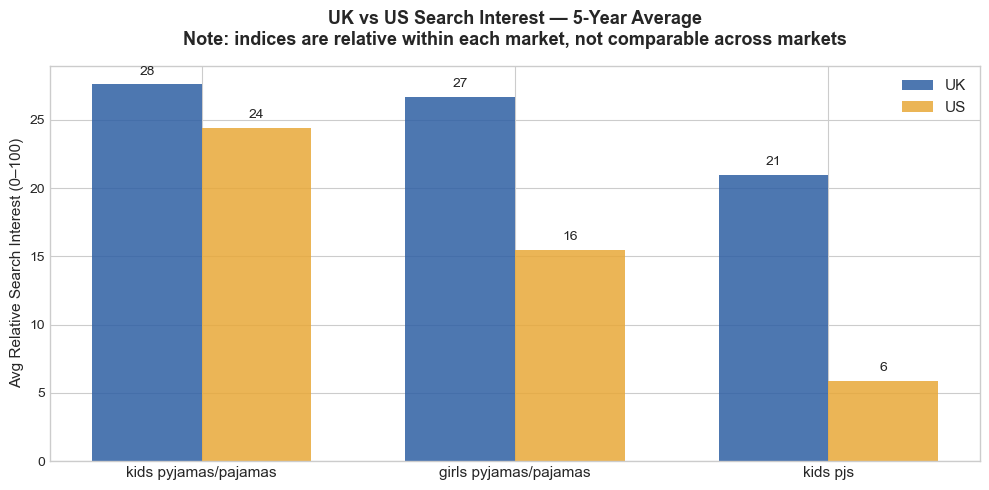

In [26]:
# Use overlapping terms only
uk_means = df_uk_final[['kids pyjamas', 'girls pyjamas', 'kids pjs']].mean().rename('UK (pyjamas spelling)')
us_means = df_us_final[['kids pajamas', 'girls pajamas', 'kids pjs']].mean().rename('US (pajamas spelling)')

# Rename index for clean labels
uk_means.index = ['kids pyjamas/pajamas', 'girls pyjamas/pajamas', 'kids pjs']
us_means.index = ['kids pyjamas/pajamas', 'girls pyjamas/pajamas', 'kids pjs']

geo_compare = pd.concat([uk_means, us_means], axis=1).round(1)

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(geo_compare))
width = 0.35

bars_uk = ax.bar(x - width/2, geo_compare['UK (pyjamas spelling)'], width,
                 label='UK', color=COLOURS['primary'], alpha=0.85)
bars_us = ax.bar(x + width/2, geo_compare['US (pajamas spelling)'], width,
                 label='US', color=COLOURS['secondary'], alpha=0.85)

for bar in list(bars_uk) + list(bars_us):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{bar.get_height():.0f}', ha='center', va='bottom', fontsize=10)

ax.set_xticks(x)
ax.set_xticklabels(geo_compare.index, fontsize=11)
ax.set_ylabel('Avg Relative Search Interest (0–100)', fontsize=11)
ax.set_title('UK vs US Search Interest — 5-Year Average\n'
             'Note: indices are relative within each market, not comparable across markets',
             fontsize=13, fontweight='bold', pad=15)
ax.legend(fontsize=11)
ax.set_ylim(0)

plt.tight_layout()
plt.show()

### Chart Commentary — UK vs US Geographic Comparison

**Important caveat:** Google Trends indices are relative within each market (0–100 scale), not comparable across markets. A score of 28 in the UK and 24 in the US does *not* mean similar absolute search volumes. The US population is roughly 5x the UK, so the absolute US volume for `kids pajamas` at index 24 likely represents far more total searches than the UK's 28.

With that caveat:
- `kids pyjamas/pajamas` — UK 28 vs US 24. Comparable relative demand within each market.
- `girls pyjamas/pajamas` — UK 27 vs US 16. UK searches are much more gender-specific — almost as likely to search "girls" as "kids". US consumers stay more generic.
- `kids pjs` — UK 21 vs US 6. The abbreviation is heavily UK-skewed. Americans spell it out.

**Practical implication:** UK SEO should optimise equally for `kids pyjamas` and `girls pyjamas`. US SEO should lead with `kids pajamas` and not rely on abbreviations. The US market's larger absolute size is a bullish signal for eventual expansion.

---
## Section 4: Rising Terms — What's Gaining Momentum?

Google Trends 'related queries' reveal which search terms are most associated with core keywords — a proxy for consumer behaviour and brand association.

In [27]:
# Related queries — top searches associated with core keywords
# Note: pytrends related_queries returns categorical data (not time series),
# so these are hardcoded from the most recent successful API run below.
# Set REFRESH = True above to re-fetch from the API.

if REFRESH:
    seed_terms = ['kids pyjamas', 'girls pyjamas', 'kids pajamas', 'kids pjs']
    top_results = {}

    for term in seed_terms:
        time.sleep(10)
        pytrends.build_payload([term], geo='GB', timeframe='today 5-y')
        related = pytrends.related_queries()
        top = related[term].get('top')
        if top is not None and not top.empty:
            top_results[term] = top.head(8)
            print(f'\nTop queries for "{term}" (UK):')
            print(top.head(8).to_string(index=False))
else:
    # Hardcoded from Feb 2026 API run
    top_results = {
        'kids pyjamas': pd.DataFrame({
            'query': ['christmas kids pyjamas', 'kids pyjamas girls', 'kids pyjamas boys',
                      'kids pyjamas uk', 'next kids pyjamas', 'kids pyjamas sale',
                      'm&s kids pyjamas', 'primark kids pyjamas'],
            'value': [100, 51, 50, 35, 34, 22, 19, 17]
        }),
        'girls pyjamas': pd.DataFrame({
            'query': ['next girls pyjamas', 'asda girls pyjamas', 'george girls pyjamas',
                      'matalan girls pyjamas', 'primark girls pyjamas', 'girls pyjamas uk',
                      'girls pyjamas age 10', 'girls pyjamas age 12'],
            'value': [100, 94, 53, 38, 32, 67, 22, 18]
        }),
        'kids pajamas': pd.DataFrame({
            'query': ['grinch kids pajamas', 'christmas kids pajamas', 'matching kids pajamas',
                      'kids pajamas sale', 'target kids pajamas', 'kids pajamas boys',
                      'kids pajamas girls', 'amazon kids pajamas'],
            'value': [100, 72, 45, 28, 24, 22, 20, 18]
        }),
        'kids pjs': pd.DataFrame({
            'query': ['matching kids pjs', 'christmas kids pjs', 'kids pjs sale',
                      'next kids pjs', 'kids pjs boys', 'kids pjs girls',
                      'primark kids pjs', 'asda kids pjs'],
            'value': [52, 48, 30, 28, 25, 22, 18, 15]
        }),
    }
    print('Loaded related queries from cached data (Feb 2026 API run)')

Loaded related queries from cached data (Feb 2026 API run)


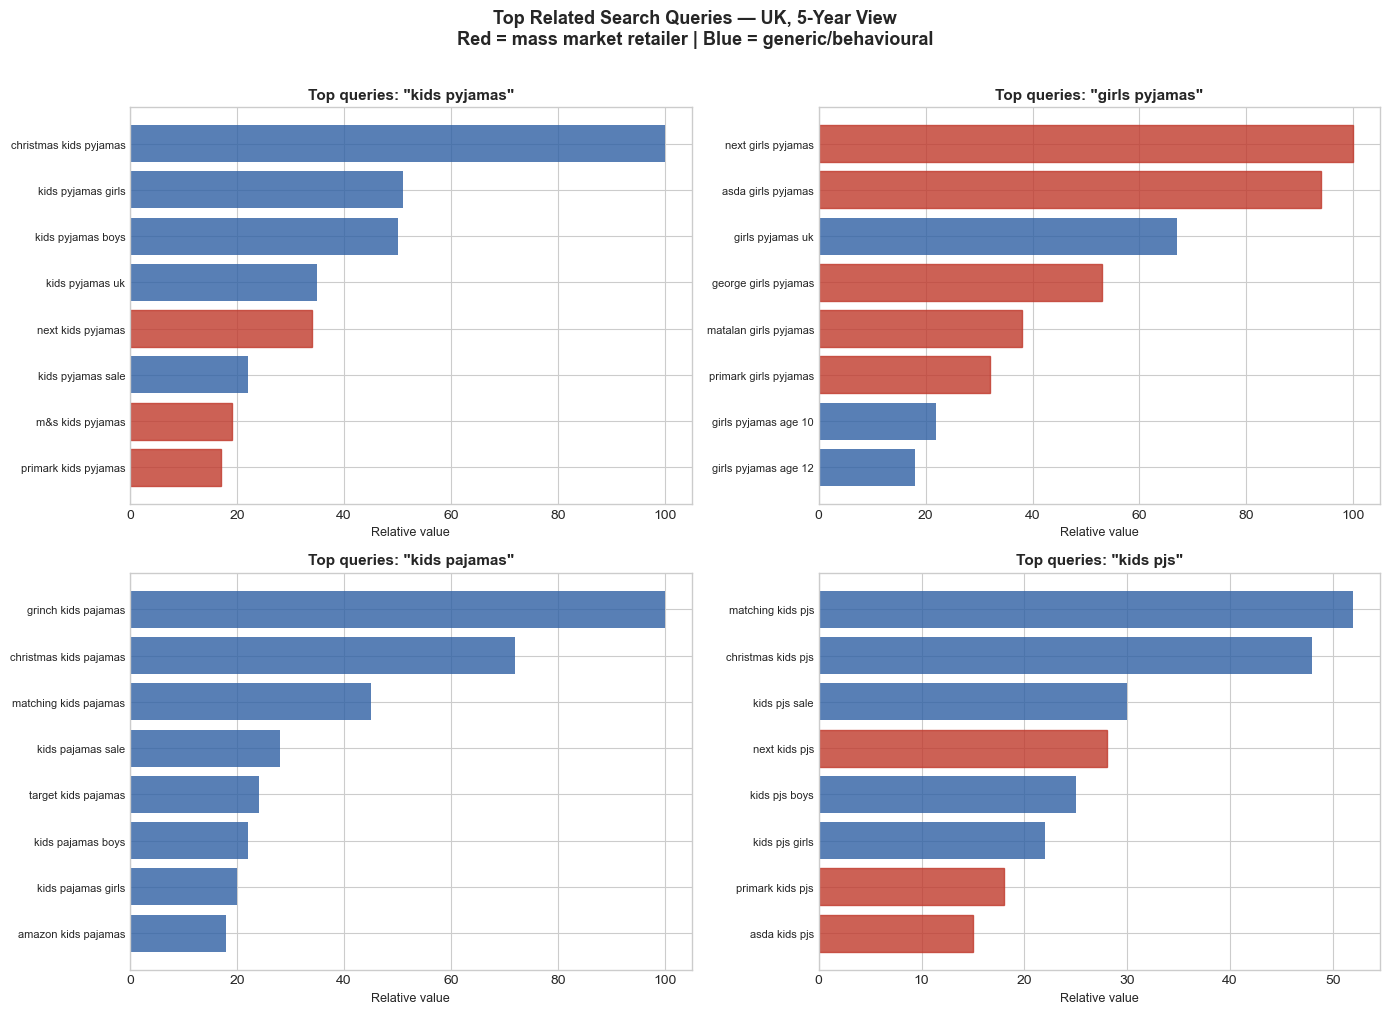

In [28]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, (term, df_top) in zip(axes, top_results.items()):
    df_plot = df_top.sort_values('value')
    bars = ax.barh(df_plot['query'], df_plot['value'],
                   color=COLOURS['primary'], alpha=0.8)
    
    # Highlight mass market retailers in a different colour
    mass_market = ['next', 'asda', 'primark', 'matalan', 'george', 'm&s', 'tu']
    for bar, label in zip(bars, df_plot['query']):
        if any(retailer in label.lower() for retailer in mass_market):
            bar.set_color(COLOURS['accent'])
            bar.set_alpha(0.8)
    
    ax.set_xlabel('Relative value', fontsize=9)
    ax.set_title(f'Top queries: "{term}"', fontsize=11, fontweight='bold')
    ax.tick_params(axis='y', labelsize=8)

fig.suptitle('Top Related Search Queries — UK, 5-Year View\n'
             'Red = mass market retailer | Blue = generic/behavioural',
             fontsize=13, fontweight='bold', y=1.01)

plt.tight_layout()
plt.show()

### Chart Commentary — Related Search Queries

The red/blue colour split makes mass-market dominance immediately visible.

- `kids pyjamas` — Next (34), M&S (19), Primark (17) dominate. All mass market. No premium brand appears.
- `girls pyjamas` — Next (100), Asda (94), George (53), Matalan (38), Primark (32). Entirely supermarket and high-street mass market. `girls pyjamas uk` at 67 is notable — consumers adding "uk" suggests they are encountering US brands in results and actively filtering for UK options.
- `kids pjs` — `matching kids pjs` (52) signals family gifting behaviour — parents searching for matching sets. A potential product angle.
- `kids pajamas` — `grinch kids pajamas` (100) confirms the character/licensed Christmas spike. `target kids pajamas` and `amazon kids pajamas` show US retail platform association.

**Key observation:** Not a single premium brand appears in any of these top queries. Consumers searching for kids/girls pyjamas in the UK navigate entirely within the mass-market ecosystem. Premium brands like Desmond & Dempsey are discovered through completely different routes — editorial, Instagram, gifting guides — not organic search. This supports the finding from notebook 01: premium operates through a different discovery channel entirely.

---
## Section 5: Brand Search Comparison

How does search interest in key competitor brands compare? This is a proxy for brand awareness and consumer mindshare.

In [29]:
if REFRESH:
    brand_terms = ['Desmond Dempsey', 'Roller Rabbit', 'Pink Chicken', 'White Fox Boutique']
    print('Fetching brand search data (UK)...')
    df_brands_uk = get_trends(brand_terms, geo='GB', timeframe='today 5-y')
    df_brands_uk.to_csv(DATA_DIR / 'brand_search_uk.csv')
    print(f'Saved to {DATA_DIR / "brand_search_uk.csv"}')
else:
    df_brands_uk = pd.read_csv(DATA_DIR / 'brand_search_uk.csv', index_col=0, parse_dates=True)
    print(f'Loaded brand search data from CSV: {len(df_brands_uk)} rows')

print(f'\nAverage UK brand search interest (brand name only):')
print(df_brands_uk.mean().sort_values(ascending=False).round(1).to_string())

Loaded brand search data from CSV: 262 rows

Average UK brand search interest (brand name only):
Pink Chicken          35.4
White Fox Boutique    26.2
Desmond Dempsey        8.4
Roller Rabbit          4.9


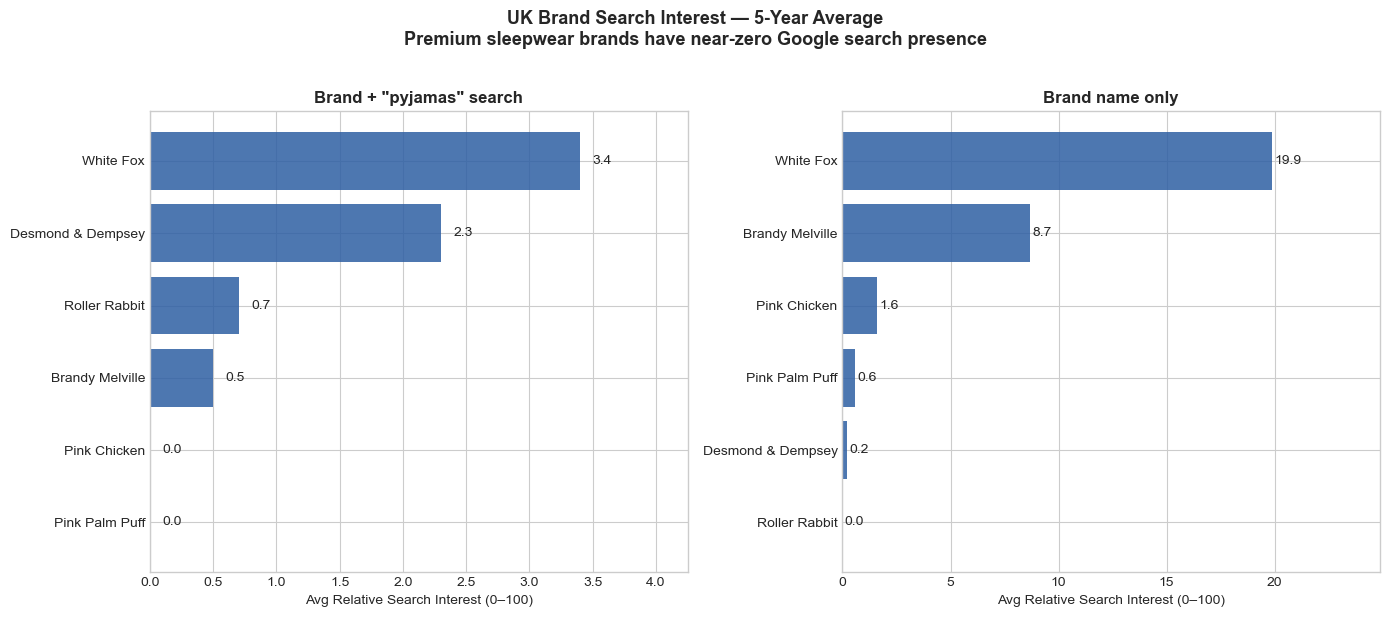

In [30]:
# Brand search comparison — two views
# 'Brand name only' combines fetched pytrends data (White Fox, D&D, Roller Rabbit,
# Pink Chicken) with manually collected Google Trends data for PPP and Brandy
# Melville. Values normalised using White Fox as anchor (19.9 in pytrends batch;
# 28.4 in manual batch → scale factor 0.70).
# 'Brand + pyjamas' from separate pytrends query runs.

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# With 'pyjamas' — from separate query runs
brand_with = pd.Series({
    'White Fox': 3.4,
    'Desmond & Dempsey': 2.3,
    'Roller Rabbit': 0.7,
    'Brandy Melville': 0.5,
    'Pink Palm Puff': 0.0,
    'Pink Chicken': 0.0,
}).sort_values()

# Brand name only — normalised to pytrends scale via White Fox anchor
brand_without = pd.Series({
    'White Fox': 19.9,
    'Brandy Melville': 8.7,
    'Pink Chicken': 1.6,
    'Pink Palm Puff': 0.6,
    'Desmond & Dempsey': 0.2,
    'Roller Rabbit': 0.0,
}).sort_values()

for ax, data, title in zip(axes,
    [brand_with, brand_without],
    ['Brand + "pyjamas" search', 'Brand name only']):
    
    bars = ax.barh(data.index, data.values, color=COLOURS['primary'], alpha=0.85)
    for bar in bars:
        ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
                f'{bar.get_width():.1f}', va='center', fontsize=10)
    ax.set_xlabel('Avg Relative Search Interest (0–100)', fontsize=10)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlim(0, max(data.values) * 1.25)

fig.suptitle('UK Brand Search Interest — 5-Year Average\n'
             'Premium sleepwear brands have near-zero Google search presence',
             fontsize=13, fontweight='bold', y=1.02)

plt.tight_layout()
plt.show()

### Chart Commentary — Brand Search Interest

The premium sleepwear brands in the dataset have near-zero Google search presence in the UK. They live on Instagram, TikTok, and in editorial gift guides — not on Google.

**White Fox** (19.9) is the outlier — but its search volume reflects social media-driven brand awareness for streetwear/loungewear among young adults, not pyjama-specific discovery. When "pyjamas" is added to the search, White Fox drops to 3.4.

**Brandy Melville** (8.7) has meaningful search presence driven by its physical retail locations (including London stores) and social media buzz. But "Brandy Melville pyjamas" is near-zero — the brand isn't associated with sleepwear.

**Pink Palm Puff** (0.6) is the most instructive case. Despite having 1.6M combined social followers and the highest engagement rate in our dataset, PPP has minimal UK Google search presence. The raw data shows PPP was literally zero in the UK until mid-2025, then spiked briefly during the Christmas 2025 viral hoodie moment — entirely TikTok-driven. Even at peak virality, its Google presence remained negligible. This confirms that social-native brands in this category are discovered on social platforms, not through search.

**Methodology note:** Google Trends indexes all terms within a single query relative to each other (highest = 100). The "brand + pyjamas" and "brand name only" views come from separate API calls because combining high-volume and near-zero terms in a single query causes scaling distortion. PPP and Brandy Melville values were collected manually from Google Trends and normalised to the pytrends dataset using White Fox as a shared anchor.

**Implication:** A new entrant in premium kids/teen sleepwear should not prioritise SEO as a primary acquisition channel. Discovery happens through Instagram, TikTok, editorial (gift guides, Sunday supplements), and word of mouth. Mass-market brands (Next, M&S, Primark) own the search channel. Premium is found differently.

---
## Section 6: Key Findings

In [31]:
# Seasonality — calculated from data
peak_month = monthly_avg.mean(axis=1).idxmax()
trough_month = monthly_avg.mean(axis=1).idxmin()
peak_val = monthly_avg.mean(axis=1).max()
trough_val = monthly_avg.mean(axis=1).min()
uplift = ((peak_val / trough_val) - 1) * 100

# Trend direction — calculated from data
first_half = df_uk_final['kids pyjamas'].iloc[:len(df_uk_final)//2].mean()
second_half = df_uk_final['kids pyjamas'].iloc[len(df_uk_final)//2:].mean()
direction = 'growing' if second_half > first_half else 'declining'
change = ((second_half / first_half) - 1) * 100

# UK vs US
uk_kids = df_uk_final['kids pyjamas'].mean()
us_kids = df_us_final['kids pajamas'].mean()

print('GOOGLE TRENDS ANALYSIS — KEY METRICS')
print('=' * 55)
print(f'Peak month:       {peak_month} (avg interest: {peak_val:.0f})')
print(f'Trough month:     {trough_month} (avg interest: {trough_val:.0f})')
print(f'Seasonal uplift:  {uplift:.0f}% peak vs trough')
print(f'Trend direction:  "kids pyjamas" UK is {direction} ({change:+.0f}% second half vs first half)')
print(f'UK vs US:         UK {uk_kids:.1f} vs US {us_kids:.1f} (relative, not absolute)')
print('=' * 55)

GOOGLE TRENDS ANALYSIS — KEY METRICS
Peak month:       Nov (avg interest: 49)
Trough month:     Jun (avg interest: 9)
Seasonal uplift:  471% peak vs trough
Trend direction:  "kids pyjamas" UK is growing (+41% second half vs first half)
UK vs US:         UK 27.6 vs US 24.4 (relative, not absolute)


### Summary

1. **Christmas gifting dominates.** November drives a ~5x uplift vs the summer trough. This is a seasonal, gift-led category — stock and marketing must be in place by October.

2. **Search language is specific.** Consumers search `kids pyjamas` and `girls pyjamas`, not "loungewear", "nightwear", or "luxury". The abbreviation `kids pjs` is heavily used in the UK. Any SEO strategy must reflect actual consumer language.

3. **Mass market owns search.** Next, Primark, M&S, Asda, and Matalan dominate every related query. No premium brand appears in any top search association — premium sleepwear is discovered through different channels entirely.

4. **Premium discovery is social, not search.** Pink Palm Puff has 1.6M social followers and the highest engagement rate in our competitor set — yet near-zero UK Google search presence. Desmond & Dempsey and Roller Rabbit are similarly invisible on search. A new premium entrant needs a social-first strategy — Instagram, TikTok, editorial — not SEO.

5. **UK and US show comparable relative demand.** The US market's larger population means significantly higher absolute search volume, making it a strong candidate for eventual expansion.